In [1]:
import os
import json
import random
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead

from torchmetrics.detection.mean_ap import MeanAveragePrecision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Device: cuda
Torch: 2.9.0+cu126
Torchvision: 0.24.0+cu126


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
DATASET_ROOT = "/kaggle/input/datasets/georgelukaanya/hospitalcocoversion"

TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, "train")
VAL_IMG_DIR   = os.path.join(DATASET_ROOT, "valid")
TEST_IMG_DIR  = os.path.join(DATASET_ROOT, "test")

TRAIN_JSON = os.path.join(TRAIN_IMG_DIR, "_annotations.coco.json")
VAL_JSON   = os.path.join(VAL_IMG_DIR, "_annotations.coco.json")
TEST_JSON  = os.path.join(TEST_IMG_DIR, "_annotations.coco.json")

for p in [TRAIN_IMG_DIR, VAL_IMG_DIR, TEST_IMG_DIR, TRAIN_JSON, VAL_JSON, TEST_JSON]:
    print(p, "->", os.path.exists(p))

/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/train -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/test -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/train/_annotations.coco.json -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/valid/_annotations.coco.json -> True
/kaggle/input/datasets/georgelukaanya/hospitalcocoversion/test/_annotations.coco.json -> True


In [4]:
with open(TRAIN_JSON, "r") as f:
    train_coco = json.load(f)

with open(VAL_JSON, "r") as f:
    val_coco = json.load(f)

with open(TEST_JSON, "r") as f:
    test_coco = json.load(f)

print("Train images:", len(train_coco["images"]))
print("Val images:", len(val_coco["images"]))
print("Test images:", len(test_coco["images"]))
print("Train annotations:", len(train_coco["annotations"]))

Train images: 5195
Val images: 272
Test images: 146
Train annotations: 8745


,class_id,class_name,train_count
0,1,Monitor,2185
1,3,bed,1930
2,6,sofa,1285
3,8,tools_table,895
4,7,stool,850
5,2,Saline Stand,770
6,5,chair,720
7,4,bin,110
8,0,tool,0


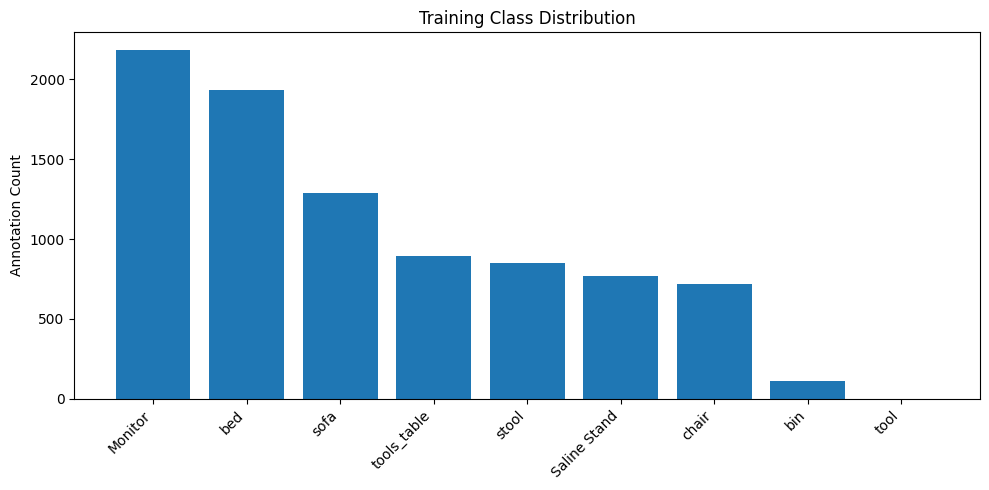

In [5]:
cat_id_to_name = {cat["id"]: cat["name"] for cat in train_coco["categories"]}
cat_name_to_id = {cat["name"]: cat["id"] for cat in train_coco["categories"]}

train_class_counts = Counter(ann["category_id"] for ann in train_coco["annotations"])

class_df = pd.DataFrame([
    {
        "class_id": cid,
        "class_name": cat_id_to_name[cid],
        "train_count": train_class_counts.get(cid, 0)
    }
    for cid in sorted(cat_id_to_name.keys())
]).sort_values("train_count", ascending=False).reset_index(drop=True)

display(class_df)

plt.figure(figsize=(10, 5))
plt.bar(class_df["class_name"], class_df["train_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Annotation Count")
plt.title("Training Class Distribution")
plt.tight_layout()
plt.show()

In [6]:
train_image_id_to_anns = defaultdict(list)
for ann in train_coco["annotations"]:
    train_image_id_to_anns[ann["image_id"]].append(ann)

train_images = train_coco["images"]

class_weights = {}
for cid in cat_id_to_name.keys():
    count = train_class_counts.get(cid, 0)
    class_weights[cid] = 1.0 / count if count > 0 else 0.0

nonzero = [w for w in class_weights.values() if w > 0]
mean_w = np.mean(nonzero)

for cid in class_weights:
    if class_weights[cid] > 0:
        class_weights[cid] /= mean_w

image_weights = []
for img in train_images:
    img_id = img["id"]
    anns = train_image_id_to_anns[img_id]
    if len(anns) == 0:
        image_weights.append(1.0)
    else:
        image_weights.append(max(class_weights[ann["category_id"]] for ann in anns))

image_weights = np.array(image_weights, dtype=np.float32)

print("Min:", image_weights.min())
print("Max:", image_weights.max())
print("Mean:", image_weights.mean())

Min: 0.2313445
Max: 4.595343
Mean: 0.51593053


In [7]:
class HospitalCocoDetectionDataset(Dataset):
    def __init__(self, coco_dict, img_dir, train=False):
        self.coco = coco_dict
        self.img_dir = img_dir
        self.train = train

        self.images = coco_dict["images"]
        self.annotations = coco_dict["annotations"]
        self.categories = coco_dict["categories"]

        self.image_id_to_anns = defaultdict(list)
        for ann in self.annotations:
            self.image_id_to_anns[ann["image_id"]].append(ann)

        self.cat_ids = sorted([cat["id"] for cat in self.categories])
        self.cat_id_to_label = {cat_id: i + 1 for i, cat_id in enumerate(self.cat_ids)}
        self.label_to_cat_id = {v: k for k, v in self.cat_id_to_label.items()}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id = img_info["id"]
        img_path = os.path.join(self.img_dir, img_info["file_name"])

        image = Image.open(img_path).convert("RGB")
        image = F.to_tensor(image)

        anns = self.image_id_to_anns[img_id]

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            x, y, w, h = ann["bbox"]

            if not np.isfinite([x, y, w, h]).all():
                continue
            if w <= 1 or h <= 1:
                continue

            x1, y1 = x, y
            x2, y2 = x + w, y + h

            boxes.append([x1, y1, x2, y2])
            labels.append(self.cat_id_to_label[ann["category_id"]])
            areas.append(w * h)
            iscrowd.append(ann.get("iscrowd", 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.train:
            image, target = self.apply_transforms(image, target)

        return image, target

    def apply_transforms(self, image, target):
        _, h, w = image.shape

        if random.random() < 0.5:
            image = torch.flip(image, dims=[2])
            boxes = target["boxes"].clone()
            boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
            target["boxes"] = boxes

        if random.random() < 0.3:
            image = F.adjust_brightness(image, random.uniform(0.9, 1.1))
            image = F.adjust_contrast(image, random.uniform(0.9, 1.1))

        return image, target

In [8]:
train_dataset = HospitalCocoDetectionDataset(train_coco, TRAIN_IMG_DIR, train=True)
val_dataset   = HospitalCocoDetectionDataset(val_coco, VAL_IMG_DIR, train=False)
test_dataset  = HospitalCocoDetectionDataset(test_coco, TEST_IMG_DIR, train=False)

def collate_fn(batch):
    return tuple(zip(*batch))

train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(image_weights),
    num_samples=len(image_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    sampler=train_sampler,
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 2598
Val batches: 136


In [9]:
num_hospital_classes = len(train_coco["categories"])
num_classes = num_hospital_classes + 1  # background included in torchvision label scheme

model = retinanet_resnet50_fpn(weights="DEFAULT")

# Replace classification head
num_anchors = model.head.classification_head.num_anchors
in_channels = model.backbone.out_channels

model.head.classification_head = RetinaNetClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

model.to(device)
print("RetinaNet ready with", num_classes, "classes including background")

Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 208MB/s]  


RetinaNet ready with 10 classes including background


In [10]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [11]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    valid_steps = 0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if not torch.isfinite(losses):
            continue

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += losses.item()
        valid_steps += 1

    return running_loss / max(valid_steps, 1)

In [12]:
@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.train()  # detection models return loss in train mode
    running_loss = 0.0
    valid_steps = 0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if torch.isfinite(losses):
            running_loss += losses.item()
            valid_steps += 1

    return running_loss / max(valid_steps, 1)

In [14]:
num_epochs = 10
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = "/kaggle/working/best_retinanet.pth"

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    lr_scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "best_val_loss": best_val_loss
        }, best_model_path)
        print("  Saved best model.")

Epoch 1/10
  Train Loss: 0.2880
  Val Loss:   0.3945
  Saved best model.
Epoch 2/10
  Train Loss: 0.2059
  Val Loss:   0.3804
  Saved best model.
Epoch 3/10
  Train Loss: 0.1670
  Val Loss:   0.4192
Epoch 4/10
  Train Loss: 0.1539
  Val Loss:   0.3846
Epoch 5/10
  Train Loss: 0.0961
  Val Loss:   0.3960
Epoch 6/10
  Train Loss: 0.0805
  Val Loss:   0.4207
Epoch 7/10
  Train Loss: 0.0781
  Val Loss:   0.4305
Epoch 8/10
  Train Loss: 0.0764
  Val Loss:   0.4447
Epoch 9/10
  Train Loss: 0.0694
  Val Loss:   0.4543
Epoch 10/10
  Train Loss: 0.0696
  Val Loss:   0.4520


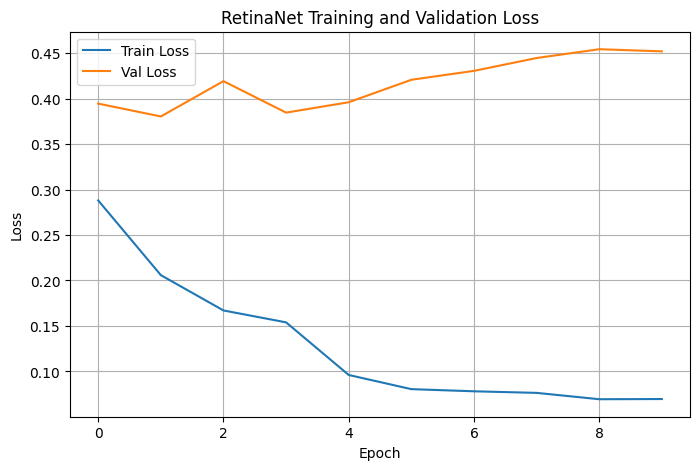

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RetinaNet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()
print("Loaded best RetinaNet model.")

Loaded best RetinaNet model.


In [17]:
@torch.no_grad()
def evaluate_map(model, loader, device):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", class_metrics=True)

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        preds = []
        gts = []

        for output, target in zip(outputs, targets):
            preds.append({
                "boxes": output["boxes"].cpu(),
                "scores": output["scores"].cpu(),
                "labels": output["labels"].cpu()
            })

            gts.append({
                "boxes": target["boxes"].cpu(),
                "labels": target["labels"].cpu()
            })

        metric.update(preds, gts)

    return metric.compute()

In [18]:
map_results = evaluate_map(model, val_loader, device)

for k, v in map_results.items():
    print(k, v)

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


map tensor(0.5609)
map_50 tensor(0.7538)
map_75 tensor(0.6166)
map_small tensor(0.)
map_medium tensor(0.1671)
map_large tensor(0.5672)
mar_1 tensor(0.6232)
mar_10 tensor(0.7324)
mar_100 tensor(0.7362)
mar_small tensor(0.)
mar_medium tensor(0.2214)
mar_large tensor(0.7434)
map_per_class tensor([0.5015, 0.6011, 0.6215, 0.1971, 0.6160, 0.7279, 0.7500, 0.4722])
mar_100_per_class tensor([0.6343, 0.7073, 0.7800, 0.7000, 0.7472, 0.8000, 0.8273, 0.6936])
classes tensor([2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.int32)


In [19]:
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - inter_area
    return inter_area / union if union > 0 else 0.0

In [20]:
label_to_cat_id = train_dataset.label_to_cat_id

@torch.no_grad()
def evaluate_per_class_metrics(model, loader, device, score_thresh=0.5, iou_thresh=0.5):
    model.eval()

    gt_counts = Counter()
    tp_counts = Counter()
    fp_counts = Counter()

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            gt_boxes = target["boxes"].numpy()
            gt_labels = target["labels"].numpy()

            pred_boxes = output["boxes"].cpu().numpy()
            pred_labels = output["labels"].cpu().numpy()
            pred_scores = output["scores"].cpu().numpy()

            keep = pred_scores >= score_thresh
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]

            matched_gt = set()

            for gt_box, gt_label in zip(gt_boxes, gt_labels):
                gt_counts[gt_label] += 1

            for pred_idx, (pred_box, pred_label) in enumerate(zip(pred_boxes, pred_labels)):
                best_iou = 0.0
                best_gt_idx = -1

                for gt_idx, (gt_box, gt_label) in enumerate(zip(gt_boxes, gt_labels)):
                    if gt_idx in matched_gt:
                        continue
                    if gt_label != pred_label:
                        continue

                    iou = compute_iou(gt_box, pred_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = gt_idx

                if best_iou >= iou_thresh and best_gt_idx != -1:
                    tp_counts[pred_label] += 1
                    matched_gt.add(best_gt_idx)
                else:
                    fp_counts[pred_label] += 1

    rows = []
    all_labels = sorted(set(list(gt_counts.keys()) + list(tp_counts.keys()) + list(fp_counts.keys())))

    for label in all_labels:
        tp = tp_counts.get(label, 0)
        fp = fp_counts.get(label, 0)
        gt = gt_counts.get(label, 0)
        fn = gt - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / gt if gt > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        fnr = fn / gt if gt > 0 else 0.0

        cat_id = label_to_cat_id[label]
        rows.append({
            "label": label,
            "class_name": cat_id_to_name[cat_id],
            "gt_count": gt,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "false_negative_rate": fnr
        })

    return pd.DataFrame(rows).sort_values("recall", ascending=True)

In [21]:
metrics_df = evaluate_per_class_metrics(model, val_loader, device, score_thresh=0.5, iou_thresh=0.5)
display(metrics_df)

,label,class_name,gt_count,tp,fp,fn,precision,recall,f1_score,false_negative_rate
3,5,bin,2,0,0,2,0.000000,0.000000,0.000000,1.000000
0,2,Monitor,102,67,14,35,0.827160,0.656863,0.732240,0.343137
7,9,tools_table,47,32,12,15,0.727273,0.680851,0.703297,0.319149
1,3,Saline Stand,41,31,5,10,0.861111,0.756098,0.805195,0.243902
6,8,stool,44,35,3,9,0.921053,0.795455,0.853659,0.204545
4,6,chair,36,29,7,7,0.805556,0.805556,0.805556,0.194444
2,4,bed,80,67,24,13,0.736264,0.837500,0.783626,0.162500
5,7,sofa,64,55,6,9,0.901639,0.859375,0.880000,0.140625


In [22]:
@torch.no_grad()
def measure_inference_speed(model, loader, device, num_batches=20):
    model.eval()
    times = []

    for i, (images, _) in enumerate(loader):
        if i >= num_batches:
            break

        images = [img.to(device) for img in images]

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()

        _ = model(images)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end = time.time()

        times.append(end - start)

    avg_time = np.mean(times)
    fps = 1.0 / avg_time if avg_time > 0 else 0.0
    return {"avg_time_sec": avg_time, "fps": fps}

In [23]:
speed_results = measure_inference_speed(model, val_loader, device)
print(speed_results)

{'avg_time_sec': np.float64(0.08789994716644287), 'fps': np.float64(11.37657111563959)}


In [24]:
def show_predictions(model, dataset, index=0, score_thresh=0.5):
    model.eval()

    image, target = dataset[index]
    image_device = image.to(device)

    with torch.no_grad():
        output = model([image_device])[0]

    image_np = image.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    ax[0].imshow(image_np)
    ax[0].set_title("Ground Truth")
    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.numpy()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        ax[0].add_patch(rect)
        class_name = cat_id_to_name[label_to_cat_id[label.item()]]
        ax[0].text(x1, y1, class_name, fontsize=10, bbox=dict(facecolor="yellow", alpha=0.5))

    ax[1].imshow(image_np)
    ax[1].set_title("RetinaNet Predictions")

    boxes = output["boxes"].cpu().numpy()
    labels = output["labels"].cpu().numpy()
    scores = output["scores"].cpu().numpy()

    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        ax[1].add_patch(rect)
        class_name = cat_id_to_name[label_to_cat_id[label]]
        ax[1].text(x1, y1, f"{class_name} {score:.2f}", fontsize=10,
                   bbox=dict(facecolor="cyan", alpha=0.5))

    plt.tight_layout()
    plt.show()

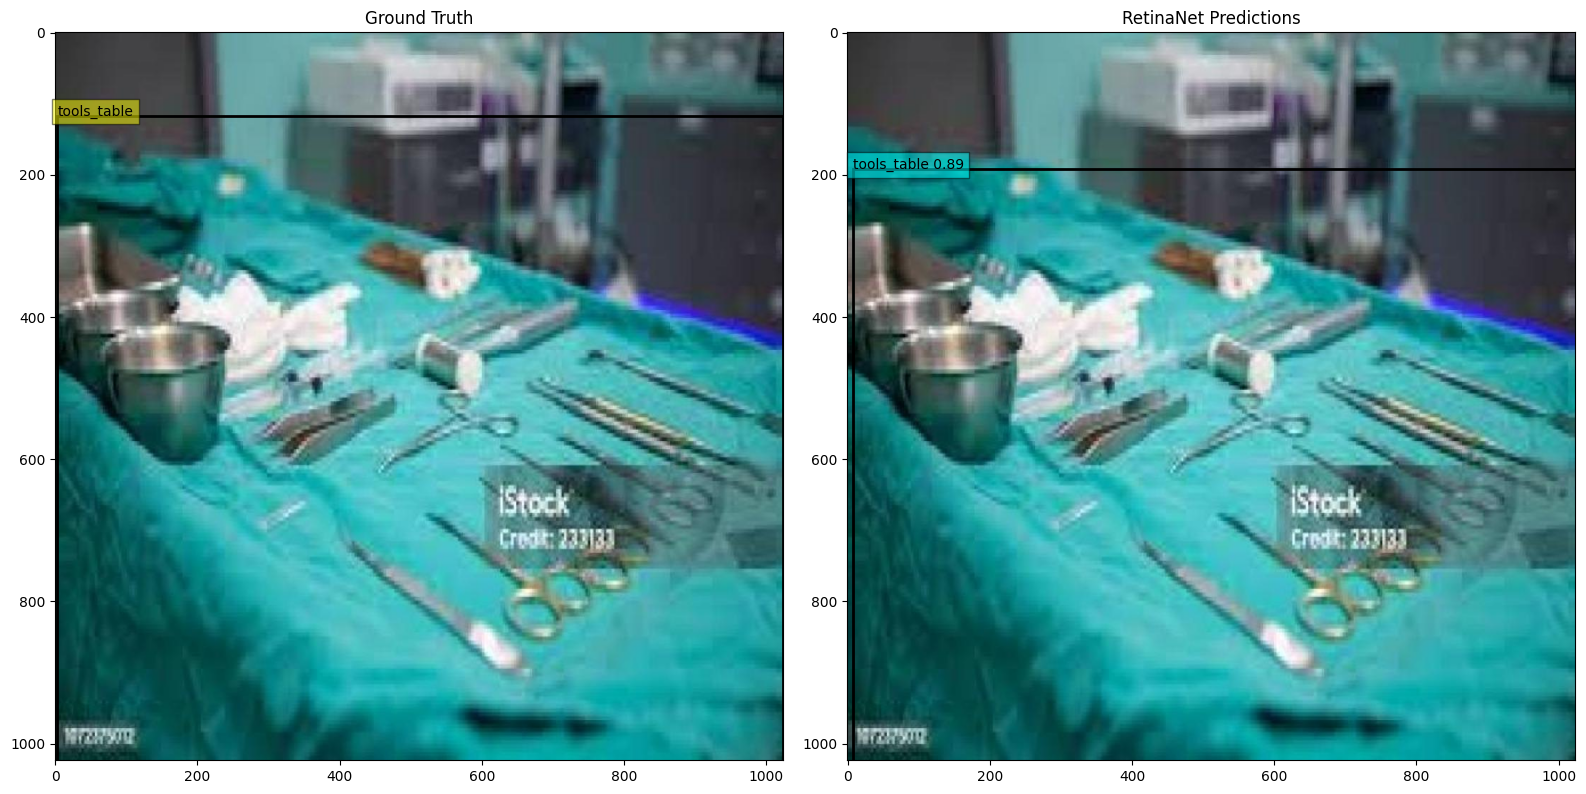

In [25]:
show_predictions(model, val_dataset, index=0, score_thresh=0.5)

In [26]:
torch.save(model.state_dict(), "/kaggle/working/retinanet_final.pth")
metrics_df.to_csv("/kaggle/working/retinanet_val_metrics.csv", index=False)

print("Saved RetinaNet model and metrics to /kaggle/working/")

Saved RetinaNet model and metrics to /kaggle/working/
